In [2]:
# Import libraries

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# don't truncate columns in pandas
pd.set_option('display.max_colwidth', None)
pd.options.display.max_rows = 300

In [3]:
# Define functions for data processing
def get_date(url):
    # GEDI02_A_2019262193446_O04362_01_T00992_02_003_01_V002_subsetted.h5 represents day 262 of 2019
    date_str = url.split('_')[2]
    year = int(date_str[:4]) 
    day = int(date_str[4:7]) 

    date = datetime(year, 1, 1) + timedelta(days = day - 1)
    return date.strftime('%Y-%m-%d')

def label_raster_val(value):
    # Handle NaN values
    if pd.isna(value):
        return 'Unknown'
    
    # Convert to int to handle float values like 7.0
    value = int(value)
    
    # Deforestation years
    if 0 <= value <= 24:
        return f'deforestation_{2000 + value}'
    
    # Regeneration years
    elif 50 <= value <= 64:
        return f'regeneration_{2010 + (value - 50)}'
    
    # Special categories
    elif value == 91:
        return 'Hidrografia'
    elif value == 100:
        return 'Vegetacao Nativa'
    elif value == 101:
        return 'Nao Floresta'
    
    # Unknown
    else:
        return 'Unknown'

In [ ]:
# Get the CSV from link - Process entire file in chunks
path = '../csv_files/gedi_prodes_joined_1.csv'

chunk_size = 100000  # Process 100k rows at a time
chunks = []

print("Reading file in chunks...")
for i, chunk in enumerate(pd.read_csv(path, chunksize=chunk_size)):
    # Apply transformations to each chunk using defined functions
    chunk['date'] = chunk['source_url'].apply(get_date)
    chunk['land_class'] = chunk['RASTERVALU'].apply(label_raster_val)
    
    # Remove rows marked as deforestation_2007
    chunk = chunk[chunk['land_class'] != 'deforestation_2007']
    
    chunks.append(chunk)
    print(f"  Processed chunk {i+1} ({len(chunk)} rows)")

# Combine all chunks
df = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")
print(df.iloc[0])

Reading file in chunks...
  Processed chunk 1 (100000 rows)
  Processed chunk 2 (100000 rows)
  Processed chunk 3 (100000 rows)
  Processed chunk 4 (100000 rows)
  Processed chunk 5 (100000 rows)
  Processed chunk 6 (100000 rows)
  Processed chunk 7 (100000 rows)
  Processed chunk 8 (100000 rows)
  Processed chunk 9 (100000 rows)
  Processed chunk 10 (100000 rows)
  Processed chunk 11 (100000 rows)
  Processed chunk 12 (100000 rows)
  Processed chunk 13 (100000 rows)
  Processed chunk 14 (100000 rows)
  Processed chunk 15 (100000 rows)
  Processed chunk 16 (100000 rows)
  Processed chunk 17 (100000 rows)
  Processed chunk 18 (100000 rows)
  Processed chunk 19 (100000 rows)
  Processed chunk 20 (100000 rows)
  Processed chunk 21 (100000 rows)
  Processed chunk 22 (100000 rows)
  Processed chunk 23 (100000 rows)
  Processed chunk 24 (100000 rows)
  Processed chunk 25 (100000 rows)
  Processed chunk 26 (100000 rows)
  Processed chunk 27 (100000 rows)
  Processed chunk 28 (100000 rows)
  P

In [5]:
# Add temporal columns for analysis
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

print(f"\nUnique land classes found:")
print(df['land_class'].unique())


Unique land classes found:
['Vegetacao Nativa' 'deforestation_2007' 'Hidrografia' 'Nao Floresta'
 'regeneration_2010' 'deforestation_2008' 'deforestation_2010'
 'regeneration_2011' 'deforestation_2024' 'deforestation_2012'
 'deforestation_2014' 'deforestation_2009' 'regeneration_2015'
 'deforestation_2023' 'regeneration_2013' 'deforestation_2019'
 'deforestation_2017' 'deforestation_2021' 'deforestation_2020'
 'regeneration_2024' 'deforestation_2011' 'regeneration_2019'
 'deforestation_2022' 'deforestation_2016' 'regeneration_2021'
 'deforestation_2013' 'regeneration_2014' 'deforestation_2018'
 'regeneration_2016' 'deforestation_2015' 'regeneration_2018'
 'regeneration_2017' 'regeneration_2020' 'regeneration_2022'
 'regeneration_2023' 'regeneration_2012' 'Unknown']


In [6]:
# Print land class distribution
print("\n=== LAND CLASS DISTRIBUTION ===")
land_class_counts = df['land_class'].value_counts()
print(land_class_counts)

print(f"\nTotal rows: {len(df):,}")


=== LAND CLASS DISTRIBUTION ===
land_class
Vegetacao Nativa      27415796
deforestation_2007     4243338
Nao Floresta           1296298
Hidrografia             191566
deforestation_2022      140634
deforestation_2021      138329
deforestation_2020      107333
deforestation_2008      100254
deforestation_2023       86975
deforestation_2019       83427
deforestation_2024       65360
deforestation_2009       64762
deforestation_2010       63662
deforestation_2018       49179
deforestation_2016       47988
deforestation_2011       47234
deforestation_2017       45303
deforestation_2015       38748
deforestation_2013       37617
deforestation_2014       30965
deforestation_2012       28684
regeneration_2015        11581
regeneration_2019         3884
regeneration_2024         3411
regeneration_2010         2249
Unknown                   2106
regeneration_2016         1708
regeneration_2023          897
regeneration_2011          844
regeneration_2013          780
regeneration_2020         

## Data Visualization

Create histograms and charts from the complete dataset.

In [7]:
# 1. Distribution of Land Classes
land_class_counts = df['land_class'].value_counts()

print(f"\nLand Class Counts:")
print(land_class_counts)


Land Class Counts:
land_class
Vegetacao Nativa      27415796
deforestation_2007     4243338
Nao Floresta           1296298
Hidrografia             191566
deforestation_2022      140634
deforestation_2021      138329
deforestation_2020      107333
deforestation_2008      100254
deforestation_2023       86975
deforestation_2019       83427
deforestation_2024       65360
deforestation_2009       64762
deforestation_2010       63662
deforestation_2018       49179
deforestation_2016       47988
deforestation_2011       47234
deforestation_2017       45303
deforestation_2015       38748
deforestation_2013       37617
deforestation_2014       30965
deforestation_2012       28684
regeneration_2015        11581
regeneration_2019         3884
regeneration_2024         3411
regeneration_2010         2249
Unknown                   2106
regeneration_2016         1708
regeneration_2023          897
regeneration_2011          844
regeneration_2013          780
regeneration_2020          758
regenera

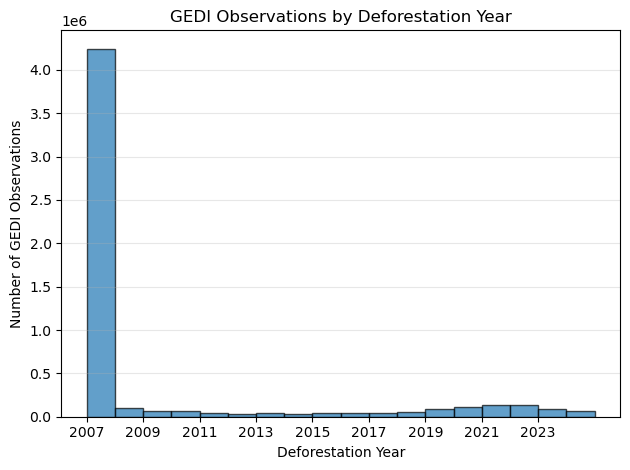


Deforestation observations: 5419792
Year range: 2007 - 2024


In [8]:

deforestation_data = df[df['land_class'].str.startswith('deforestation_', na=False)]
deforestation_years = deforestation_data['land_class'].str.replace('deforestation_', '').astype(int)

plt.hist(deforestation_years, bins=range(2007, 2026), edgecolor='black', alpha=0.7)
plt.xlabel('Deforestation Year')
plt.ylabel('Number of GEDI Observations')
plt.title('GEDI Observations by Deforestation Year')
plt.xticks(range(2007, 2025, 2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDeforestation observations: {len(deforestation_data)}")
print(f"Year range: {deforestation_years.min()} - {deforestation_years.max()}")

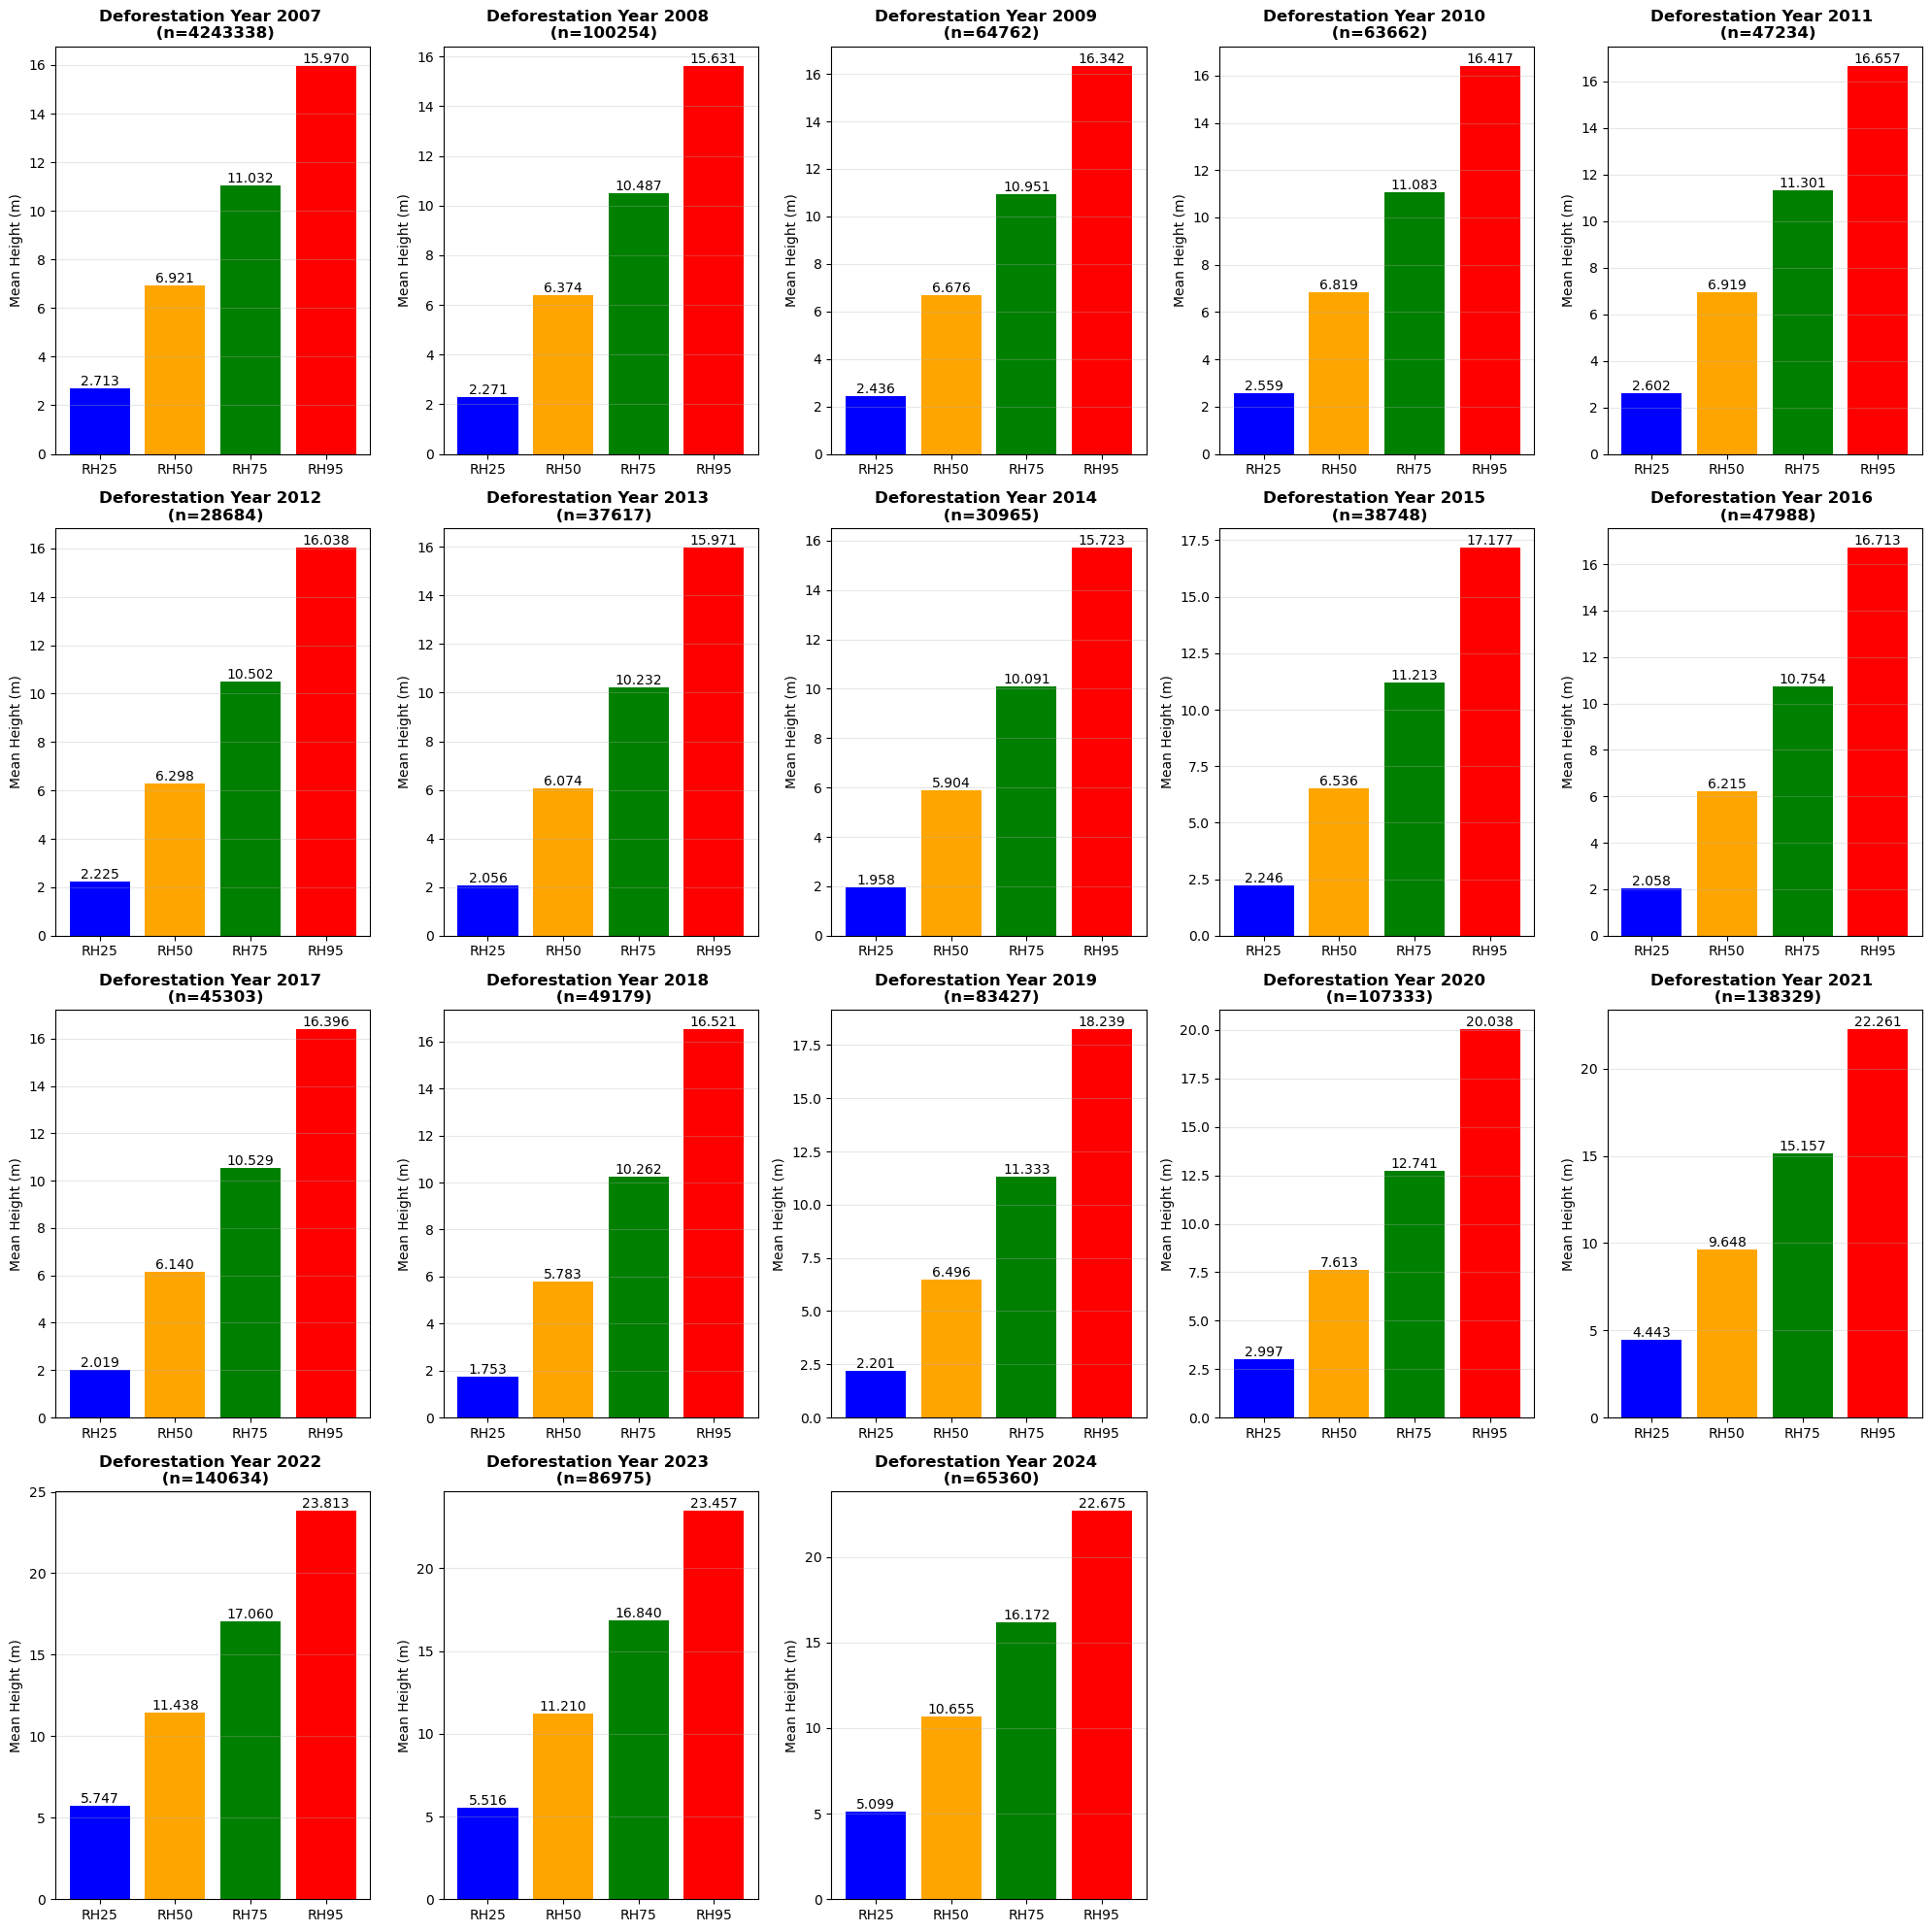

In [9]:
# Bar charts for each deforestation year showing all 4 rh metrics

deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)

years = sorted(deforestation_df['deforestation_year'].unique())
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

# rows/columns needed for subplots
n_years = len(years)
n_cols = 5
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    
    # Calc mean heights for each rh value
    mean_heights = [year_data[metric].mean() for metric in metrics]
    
    # Create bar chart
    bars = ax.bar(['RH25', 'RH50', 'RH75', 'RH95'], mean_heights, 
                   color=['blue', 'orange', 'green', 'red'])
    
    ax.set_ylabel('Mean Height (m)')
    ax.set_title(f'Deforestation Year {year} \n (n={len(year_data)})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # label bars with values
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')


# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout() 
plt.show()

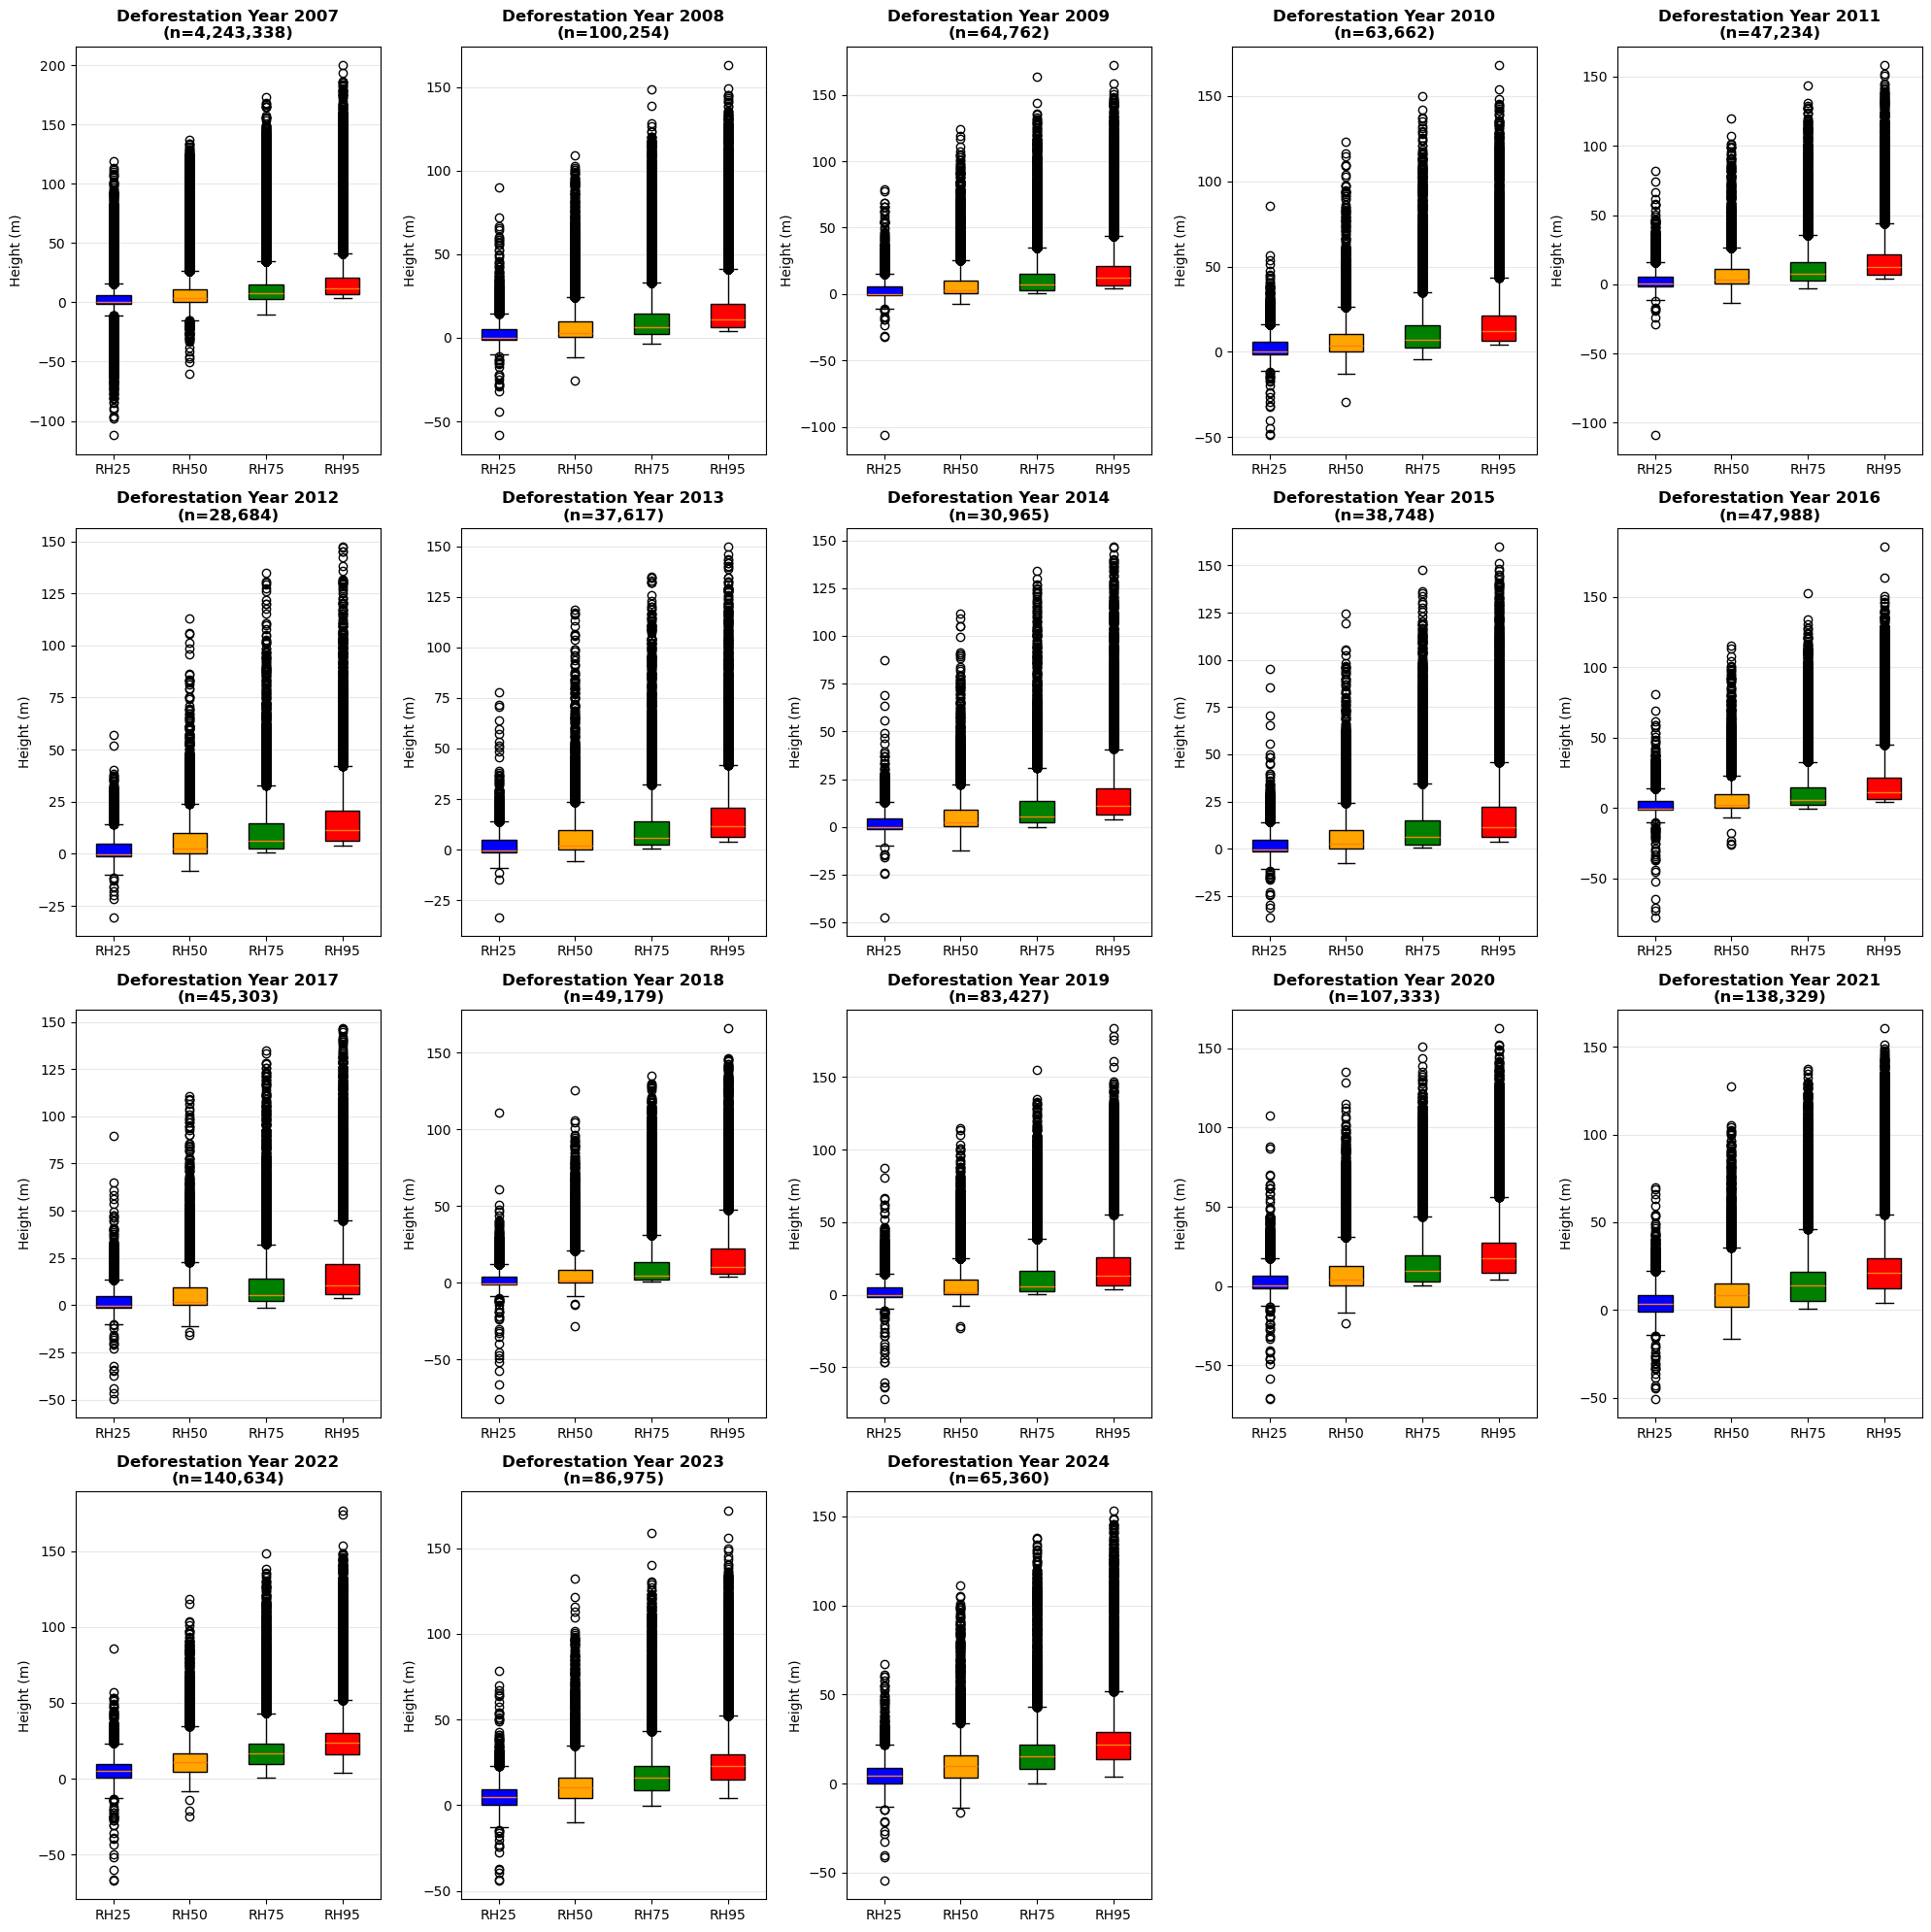


=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR ===

Deforestation Year 2007 (n=4,243,338):
       rh25    rh50    rh75    rh95
min -112.22  -60.08  -10.71    4.00
25%   -1.11    0.44    2.62    6.76
50%    0.48    3.85    7.55   11.98
75%    5.80   10.84   15.39   20.44
max  119.13  137.23  173.35  200.27 


Deforestation Year 2008 (n=100,254):
      rh25    rh50    rh75    rh95
min -58.34  -25.65   -3.48    4.00
25%  -1.23    0.33    2.39    6.36
50%  -0.07    2.80    6.39   11.26
75%   5.14    9.98   14.67   20.26
max  89.69  108.88  148.29  163.20 


Deforestation Year 2009 (n=64,762):
       rh25    rh50    rh75    rh95
min -106.48   -7.49    0.74    4.00
25%   -1.19    0.37    2.47    6.58
50%    0.11    3.14    6.89   11.98
75%    5.37   10.41   15.36   21.30
max   78.63  124.39  163.30  172.52 


Deforestation Year 2010 (n=63,662):
      rh25    rh50    rh75    rh95
min -48.95  -29.58   -4.52    4.00
25%  -1.19    0.41    2.58    6.69
50%   0.29    3.48    7.25   12.24
75%   5.69  

In [10]:
# Boxplots for each deforestation year showing all 4 rh metrics

deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)

years = sorted(deforestation_df['deforestation_year'].unique())
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

# rows/columns needed for subplots
n_years = len(years)
n_cols = 4
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    
    data_by_metric = [year_data[metric] for metric in metrics]
    
    # create boxplot
    bp = ax.boxplot(data_by_metric, tick_labels=['RH25', 'RH50', 'RH75', 'RH95'], patch_artist=True)
    
    # color boxes
    colors = ['blue', 'orange', 'green', 'red']
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
    
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Deforestation Year {year}\n(n={len(year_data):,})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("\n=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR ===\n")
for year in years:
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    print(f"Deforestation Year {year} (n={len(year_data):,}):")
    summary = year_data[metrics].describe().loc[['min', '25%', '50%', '75%', 'max']]
    print(summary.round(2), '\n\n')



Mean canopy heights by years since deforestation:
years_since_deforestation
0     7.18
1     5.95
2     5.67
3     6.02
4     6.23
5     6.26
6     6.04
7     6.16
8     6.57
9     6.75
10    6.82
11    6.63
12    7.59
13    6.69
14    6.72
15    6.23
Name: mean, dtype: float64


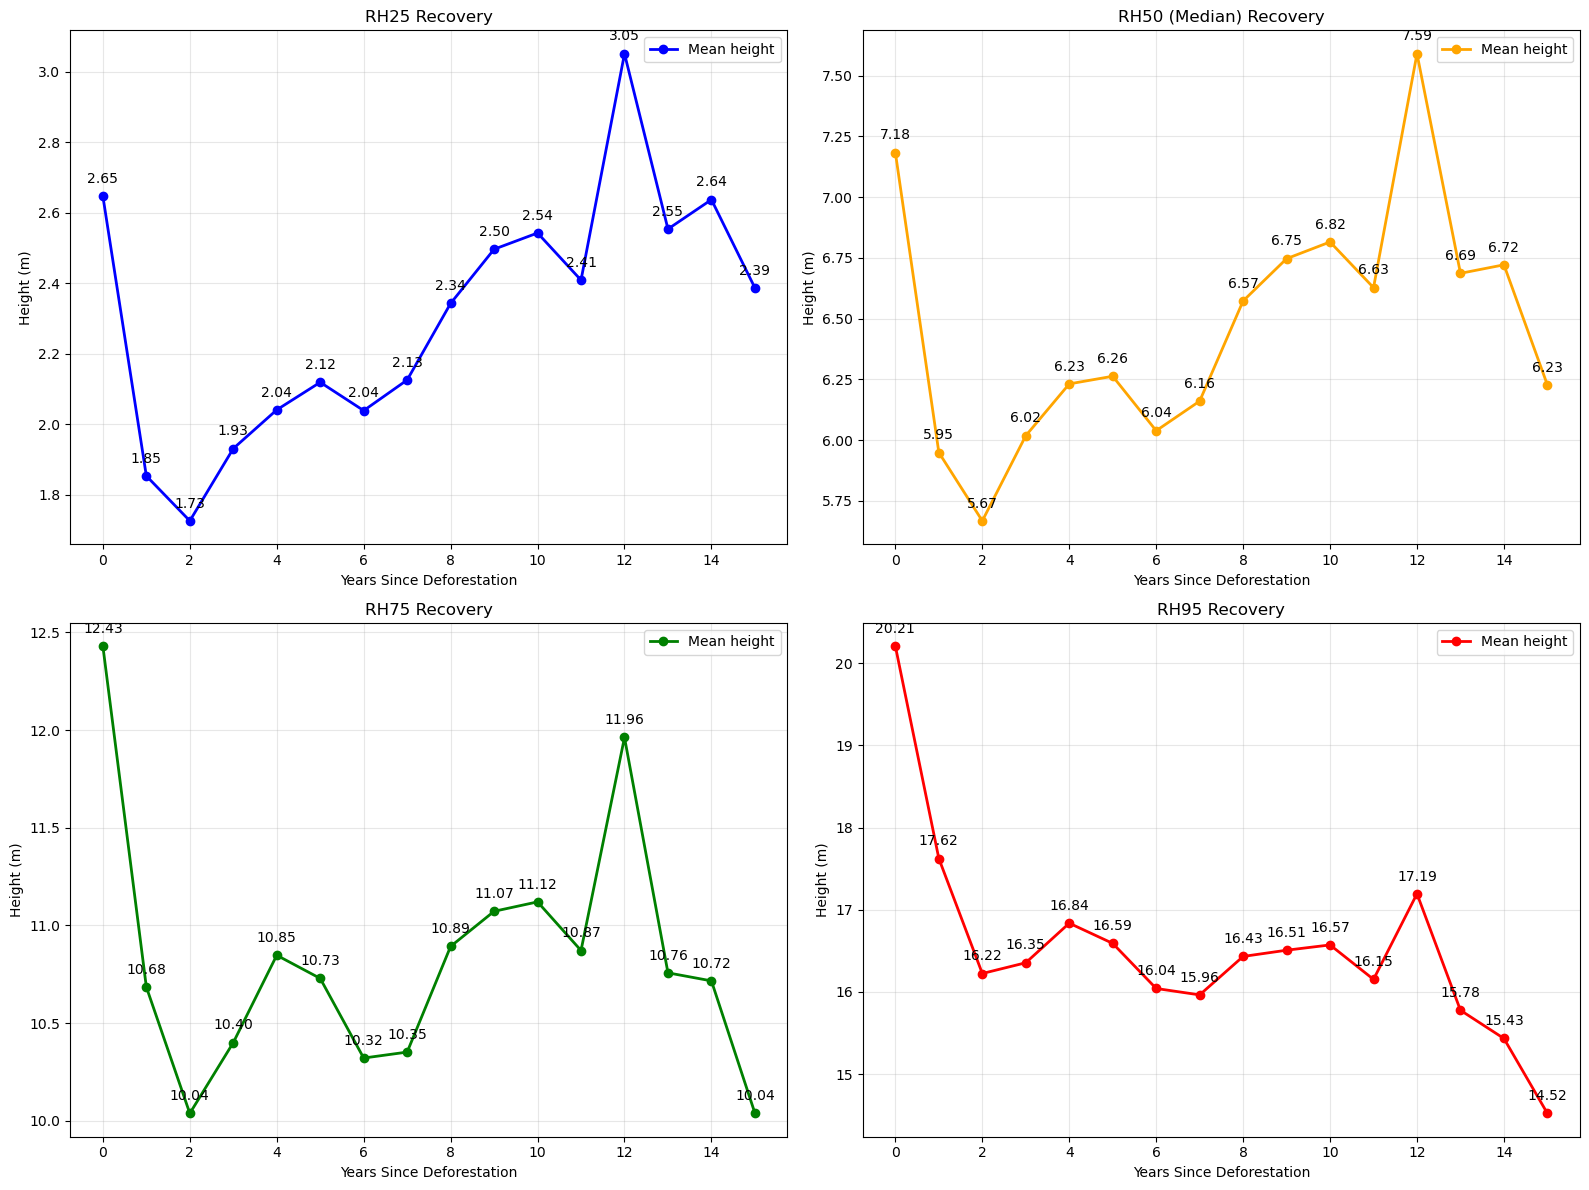

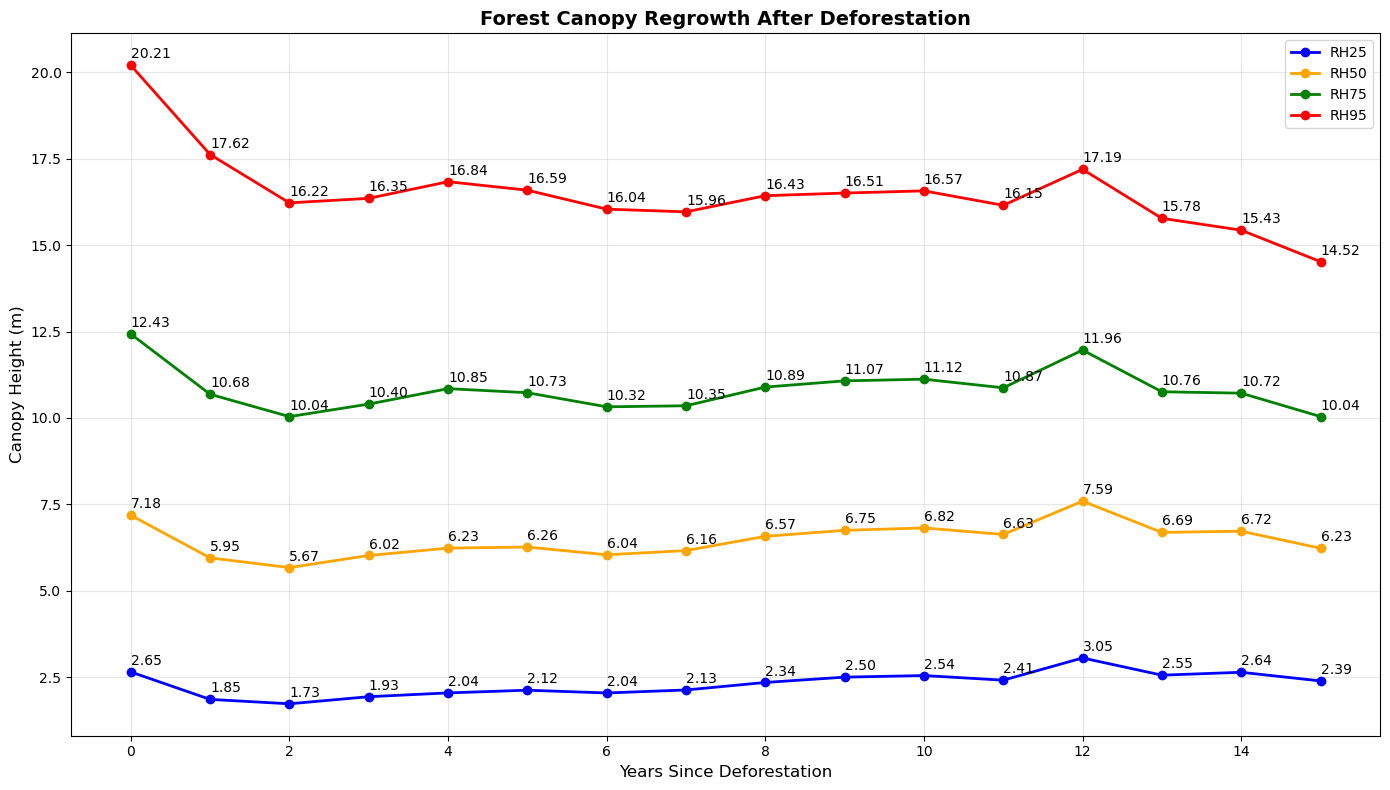

In [38]:
deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)
deforestation_df['years_since_deforestation'] = deforestation_df['year'] - deforestation_df['deforestation_year']
deforestation_df = deforestation_df[deforestation_df['years_since_deforestation'] >= 0]

# mean heights by years since deforestation
regrowth_stats = deforestation_df.groupby('years_since_deforestation')[['rh25', 'rh50', 'rh75', 'rh95']].agg(['mean'])

print("\nMean canopy heights by years since deforestation:")
print(regrowth_stats['rh50']['mean'].round(2))

# Visualization: Height recovery over time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['rh25', 'rh50', 'rh75', 'rh95']
titles = ['RH25 Recovery', 'RH50 (Median) Recovery', 'RH75 Recovery', 'RH95 Recovery']
colors = ['blue', 'orange', 'green', 'red']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    
    years = regrowth_stats.index
    means = regrowth_stats[metric]['mean']
    
    # plot mean
    ax.plot(years, means, marker='o', linewidth=2, color=color, label='Mean height')
    
    ax.set_xlabel('Years Since Deforestation')
    ax.set_ylabel('Height (m)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    #label each point with its value
    for x, y in zip(years, means, ):
        y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        ax.text(x, y + y_offset, f'{y:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Show all charts combined
plt.figure(figsize=(14, 8))
for metric, color, label in zip(metrics, colors, ['RH25', 'RH50', 'RH75', 'RH95']):
    means = regrowth_stats[metric]['mean']
    plt.plot(regrowth_stats.index, means, marker='o', linewidth=2, color=color, label=label)

    #label each point with its value
    for x, y in zip(regrowth_stats.index, means):
        plt.text(x, y + 0.2, f'{y:.2f}')

plt.xlabel('Years Since Deforestation', fontsize=12)
plt.ylabel('Canopy Height (m)', fontsize=12)
plt.title('Forest Canopy Regrowth After Deforestation', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
# IGNORE - AI GENERATED FOR TESTING

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# metrics = ['rh25', 'rh50', 'rh75', 'rh95']
# titles = ['RH25 (25th percentile height)', 'RH50 (Median height)', 
#           'RH75 (75th percentile height)', 'RH95 (95th percentile height)']

# for idx, (metric, title) in enumerate(zip(metrics, titles)):
#     ax = axes[idx // 2, idx % 2]
    
#     # Create boxplot for each land class
#     land_classes = df['land_class'].unique()
#     data_by_class = [df[df['land_class'] == lc][metric].dropna() for lc in land_classes]
    
#     ax.boxplot(data_by_class, tick_labels=land_classes)
#     ax.set_ylabel('Height (m)')
#     ax.set_title(title)
#     ax.tick_params(axis='x', rotation=45)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Summary statistics
# print("\nCanopy Height Summary by Land Class:")
# print(df.groupby('land_class')[metrics].mean().round(2))